In [1]:
import numpy as np
import scipy.stats as stats
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
import pymc as pm
import pytensor.tensor as pt

np.random.seed(42)
sns.set_theme(style="whitegrid")

In [2]:
# --- Cluster parameters ---
n_samples   = 300
true_k      = 3
mix_weights = [0.4, 0.35, 0.25]

means = np.array([
    [0.0,  0.0],
    [5.0,  2.0],
    [2.0,  6.0],
])

covs = np.array([
    [[1.0, 0.3],  [0.3,  0.8]],
    [[1.2, -0.4], [-0.4, 1.0]],
    [[0.8, 0.2],  [0.2,  1.5]],
])

# --- Sample data ---
cluster_sizes = np.random.multinomial(n_samples, mix_weights)
X_list, z_list = [], []

for k, (n, mu, sigma) in enumerate(zip(cluster_sizes, means, covs)):
    X_list.append(np.random.multivariate_normal(mu, sigma, n))
    z_list.append(np.full(n, k))

X = np.vstack(X_list)          # shape (N, 2)
z = np.concatenate(z_list)     # true cluster labels

df = pd.DataFrame(X, columns=["x1", "x2"])
df["cluster"] = z.astype(str)

print(f"Total points: {len(X)}  |  Cluster counts: {dict(zip(*np.unique(z, return_counts=True)))}")

Total points: 300  |  Cluster counts: {0: 115, 1: 106, 2: 79}


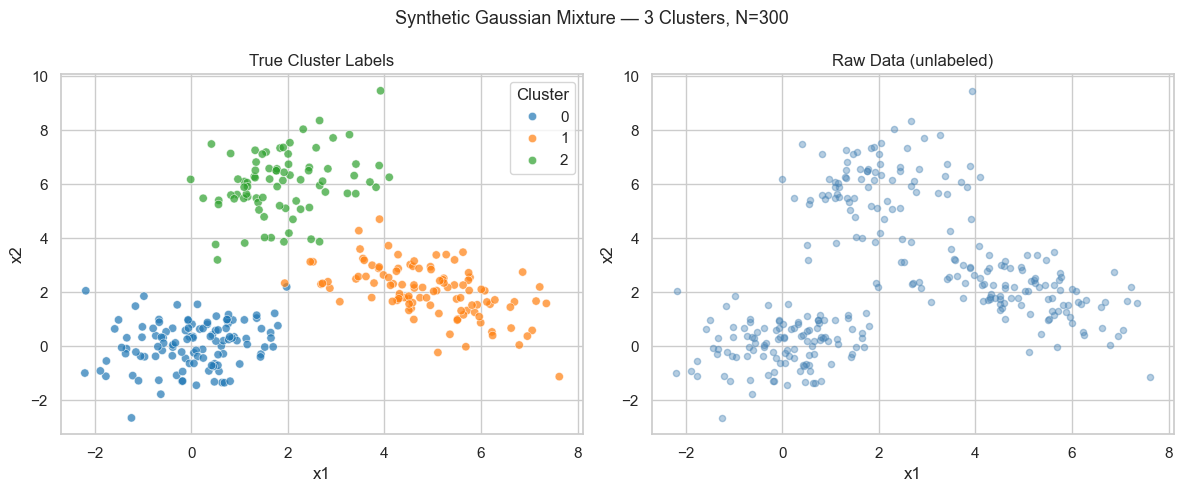

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: colored by true cluster ---
sns.scatterplot(data=df, x="x1", y="x2", hue="cluster",
                palette="tab10", alpha=0.7, ax=axes[0])
axes[0].set_title("True Cluster Labels")
axes[0].legend(title="Cluster")

# --- Right: no labels (as the DP will see it) ---
axes[1].scatter(X[:, 0], X[:, 1], color="steelblue", alpha=0.4, s=20)
axes[1].set_title("Raw Data (unlabeled)")
axes[1].set_xlabel("x1")
axes[1].set_ylabel("x2")

plt.suptitle("Synthetic Gaussian Mixture — 3 Clusters, N=300", fontsize=13)
plt.tight_layout()
plt.show()

In [4]:
K_max = 10   # truncation: max number of components DP can use
N, D  = X.shape

with pm.Model() as dp_model:

    # --- Concentration parameter (alpha) ---
    alpha = pm.Gamma("alpha", alpha=1.0, beta=1.0)

    # --- Stick-breaking weights ---
    v = pm.Beta("v", alpha=1.0, beta=alpha, shape=K_max - 1)
    v_cumprod   = pt.concatenate([[1.0], pt.cumprod(1.0 - v)])
    stick_weights = pt.concatenate([v, [1.0]]) * v_cumprod
    w = pm.Deterministic("w", stick_weights / stick_weights.sum())

    # --- Component means and standard deviations ---
    mu    = pm.Normal("mu",    mu=0.0,  sigma=5.0, shape=(K_max, D))
    sigma = pm.HalfNormal("sigma", sigma=2.0,      shape=(K_max, D))

    # --- Mixture likelihood (MvNormal with diagonal covariance) ---
    comp_dists = [pm.MvNormal.dist(mu=mu[k], cov=pt.diag(sigma[k] ** 2)) for k in range(K_max)]
    obs = pm.Mixture("obs", w=w, comp_dists=comp_dists, observed=X)

print(dp_model)

In [5]:
with dp_model:
    trace = pm.sample(
        draws=1000,
        tune=1000,
        chains=2,
        target_accept=0.9,
        random_seed=42,
        progressbar=True,
    )

print(pm.summary(trace, var_names=["alpha", "w"]))

Initializing NUTS using jitter+adapt_diag...
c:\Users\felip\anaconda3\Lib\site-packages\pytensor\link\c\cmodule.py:2959: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, v, mu, sigma]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 3163 seconds.
There were 5 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
alpha  0.804  0.428   0.148    1.601      0.027    0.014     226.0     265.0   
w[0]   0.248  0.044   0.161    0.326      0.014    0.002      10.0     257.0   
w[1]   0.248  0.135   0.067    0.426      0.093    0.001       3.0     237.0   
w[2]   0.256  0.040   0.177    0.325      0.011    0.002      13.0     131.0   
w[3]   0.217  0.161   0.000    0.407      0.111    0.018       3.0      17.0   
w[4]   0.025  0.039   0.000    0.107      0.020    0.014       6.0      25.0   
w[5]   0.004  0.013   0.000    0.017      0.001    0.004     157.0     116.0   
w[6]   0.001  0.003   0.000    0.006      0.000    0.000     215.0     204.0   
w[7]   0.001  0.004   0.000    0.003      0.000    0.002     130.0     188.0   
w[8]   0.000  0.001   0.000    0.001      0.000    0.000     148.0     199.0   
w[9]   0.000  0.002   0.000    0.002      0.000    0.001     109.0     200.0   

       r_hat  
alpha   1.01  
w[0]    1